In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display

from mtlib.nn import (
    GridConfig,
    ResUNetAttention,
    RouteExtractionConfig,
    TrackInpaintDataset,
    load_checkpoint,
    load_frags,
    load_track_index,
    make_route_comparison_figure,
    make_route_extraction_grid_figure,
    predict_and_extract_route,
    predict_dataset_routes,
    read_track_fragment,
    save_route_comparison_png,
)

plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = False

/Users/mark/Documents/Frameworks/conda/envs/marinetime/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATASET_PATH = Path("/Users/mark/Documents/Works/MT_Dataset/mt_tracks_20250714_tsorted.h5")
ARTIFACT_DIR = Path("/Users/mark/Documents/Works/MT_Dataset/atrifacts_mt_tracks_20250714_tsorted")
CHECKPOINT_PATH = Path("/Users/mark/Documents/Works/MT_Dataset/runs/mt_tracks_20250714_tsorted_22-04-26/checkpoints/best.pt")
OUT_DIR =  Path("./runs/28-track-restore-mtlib")
OUT_DIR.mkdir(parents=True, exist_ok=True)

for path in [DATASET_PATH, ARTIFACT_DIR, CHECKPOINT_PATH]:
    assert path.exists(), f'Missing path: {path}'

print(f'DATASET_PATH   : {DATASET_PATH}')
print(f'ARTIFACT_DIR   : {ARTIFACT_DIR}')
print(f'CHECKPOINT_PATH: {CHECKPOINT_PATH}')
print(f'OUT_DIR        : {OUT_DIR}')

DATASET_PATH   : /Users/mark/Documents/Works/MT_Dataset/mt_tracks_20250714_tsorted.h5
ARTIFACT_DIR   : /Users/mark/Documents/Works/MT_Dataset/atrifacts_mt_tracks_20250714_tsorted
CHECKPOINT_PATH: /Users/mark/Documents/Works/MT_Dataset/runs/mt_tracks_20250714_tsorted_22-04-26/checkpoints/best.pt
OUT_DIR        : runs/28-track-restore-mtlib


In [3]:
grid_cfg = GridConfig()
extract_cfg = RouteExtractionConfig()
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

frags_train = load_frags(ARTIFACT_DIR / 'frags_train.parquet')
frags_val = load_frags(ARTIFACT_DIR / 'frags_val.parquet')
track_index = load_track_index(ARTIFACT_DIR / 'track_index.pkl')

train_ds = TrackInpaintDataset(
    dataset_path=DATASET_PATH,
    frags_path=ARTIFACT_DIR / 'frags_train.parquet',
    track_index_path=ARTIFACT_DIR / 'track_index.pkl',
    density_path=ARTIFACT_DIR / 'density.npz',
    grid_cfg=grid_cfg,
    seed=123,
    return_meta=True,
)

val_ds = TrackInpaintDataset(
    dataset_path=DATASET_PATH,
    frags_path=ARTIFACT_DIR / 'frags_val.parquet',
    track_index_path=ARTIFACT_DIR / 'track_index.pkl',
    density_path=ARTIFACT_DIR / 'density.npz',
    grid_cfg=grid_cfg,
    seed=123,
    return_meta=True,
)

model = ResUNetAttention(in_ch=4, out_ch=1, base_ch=32, groups=8, attn_heads=4).to(device)
load_checkpoint(CHECKPOINT_PATH, model=model, map_location=device)
model.eval()

print('device       :', device)
print('train frags  :', len(frags_train))
print('val frags    :', len(frags_val))
print('track index  :', len(track_index))
print('train_ds len :', len(train_ds))
print('val_ds len   :', len(val_ds))

device       : mps
train frags  : 57986
val frags    : 1196
track index  : 113917
train_ds len : 57986
val_ds len   : 1196


In [4]:
DEMO_SPLIT = 'val'
DEMO_INDEX = 0
demo_ds = val_ds if DEMO_SPLIT == 'val' else train_ds
demo_example = demo_ds[DEMO_INDEX]
demo_meta = demo_example['meta']

h5 = h5py.File(DATASET_PATH, 'r')
demo_fragment = read_track_fragment(
    h5,
    demo_ds.track_index,
    demo_meta['track_id'],
    demo_meta['s'],
    demo_meta['e'],
)

display(pd.DataFrame([demo_meta]))
print('fragment points:', len(demo_fragment))
print('gap           :', demo_meta['gaps'][0])

,idx,track_id,s,e,points,t0,t1,extent,gaps
0,0,3661,21,68,47,1730215421,1730243318,"[133.7976171528605, 135.3065851176473, 33.8940...","[(5, 42)]"


fragment points: 47
gap           : (5, 42)


In [5]:
demo_prob_map, demo_result = predict_and_extract_route(
    model,
    demo_example,
    demo_fragment,
    grid_cfg=grid_cfg,
    device=device,
    extract_config=extract_cfg,
)

known = demo_example['x'].numpy()[0]

print('path source      :', demo_result.path_source)
print('path length      :', len(demo_result.path_cells))
print('mean prob on path:', demo_result.mean_prob_on_path)
print('start cell       :', demo_result.artifacts.start_cell)
print('end cell         :', demo_result.artifacts.end_cell)
print('graph nodes      :', demo_result.artifacts.graph.number_of_nodes())
print('graph edges      :', demo_result.artifacts.graph.number_of_edges())

path source      : skeleton graph
path length      : 108
mean prob on path: 0.9952637553215027
start cell       : (56, 21)
end cell         : (78, 121)
graph nodes      : 134
graph edges      : 147


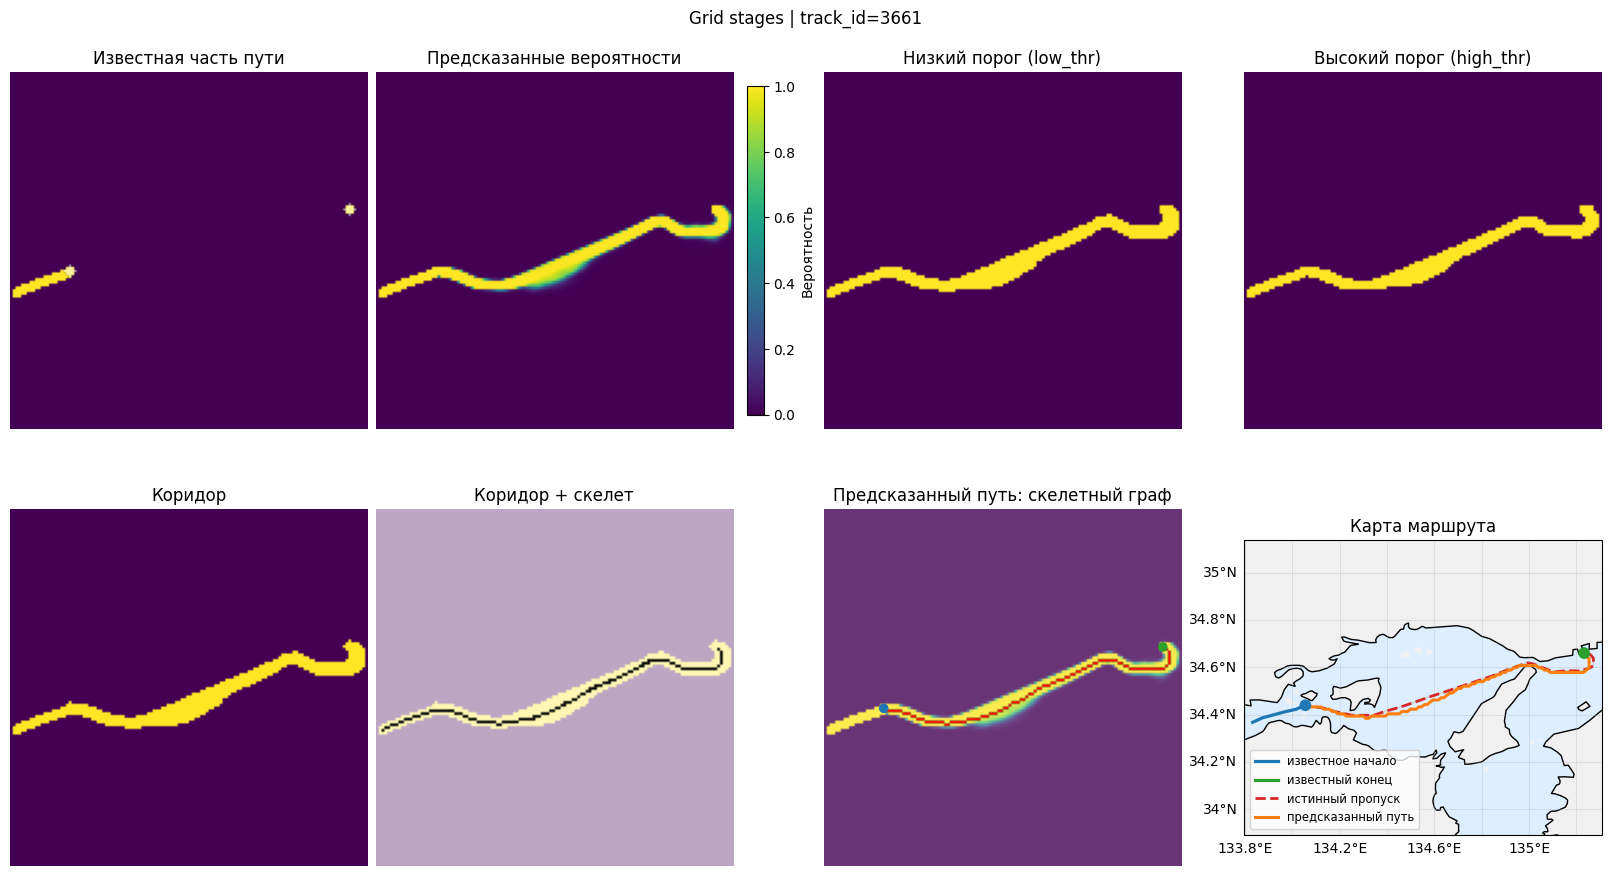

In [6]:
fig_grid = make_route_extraction_grid_figure(
    demo_prob_map,
    known,
    demo_result,
    demo_fragment,
    tuple(demo_meta['gaps'][0]),
    demo_meta['extent'],
    title=f"Grid stages | track_id={demo_meta['track_id']}",
)
plt.show()

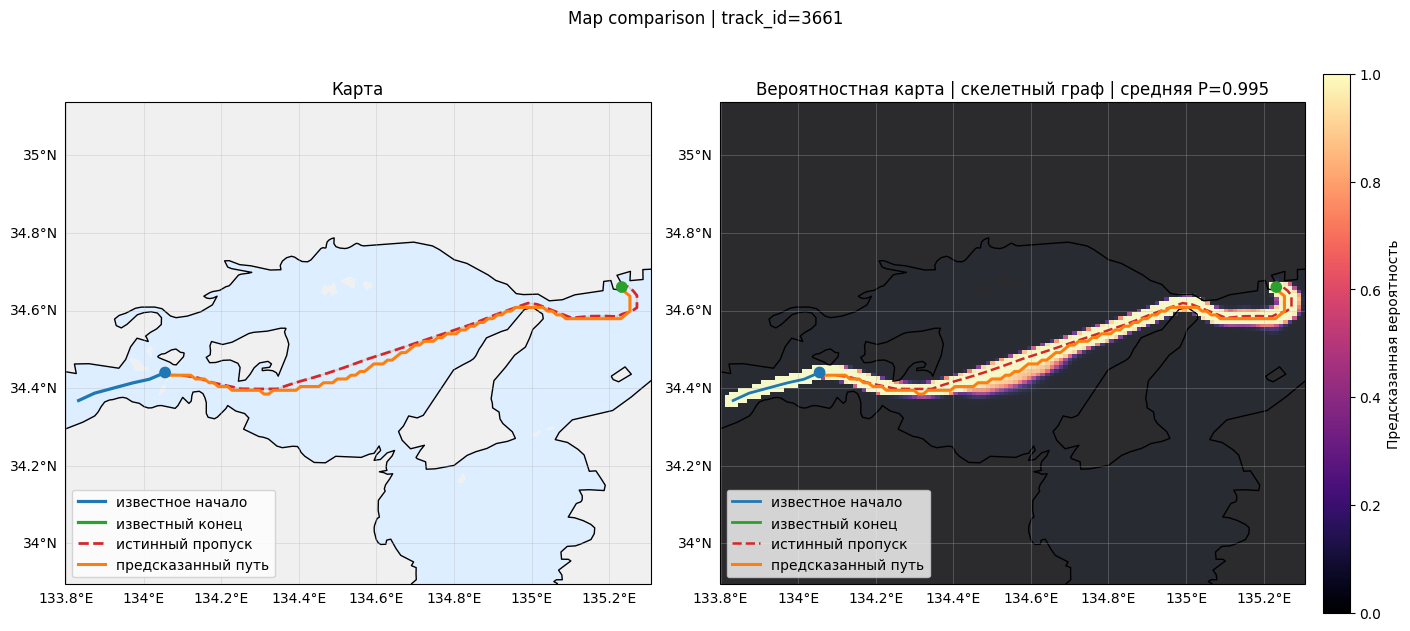

In [7]:
demo_gap = tuple(demo_meta['gaps'][0])
demo_extent = demo_meta['extent']

fig_map = make_route_comparison_figure(
    demo_fragment,
    demo_gap,
    demo_extent,
    demo_prob_map,
    demo_result,
    title=f"Map comparison | track_id={demo_meta['track_id']}",
)
plt.show()

In [8]:
single_png = OUT_DIR / f"demo_track_{demo_meta['track_id']}.png"
save_route_comparison_png(
    single_png,
    demo_fragment,
    demo_gap,
    demo_extent,
    demo_prob_map,
    demo_result,
    title=f"mtlib demo | track_id={demo_meta['track_id']}",
)
print(single_png)

runs/28-track-restore-mtlib/demo_track_3661.png


In [9]:
BATCH_INDICES = [0, 1, 2, 3, 4] if len(val_ds) >= 5 else list(range(len(val_ds)))
batch_df = predict_dataset_routes(
    model,
    val_ds,
    grid_cfg=grid_cfg,
    device=device,
    indices=BATCH_INDICES,
    extract_config=extract_cfg,
    progress=True,
)

display(batch_df[['idx', 'track_id', 's', 'e', 'path_source', 'path_len', 'mean_prob_on_path', 'graph_nodes', 'graph_edges']])

Predict dataset routes: 100%|██████████| 5/5 [00:00<00:00, 64.49it/s]


,idx,track_id,s,e,path_source,path_len,mean_prob_on_path,graph_nodes,graph_edges
0,0,3661,21,68,skeleton graph,108,0.995264,134,147
1,1,4707,6,71,skeleton graph,118,0.999852,140,165
2,2,50648,0,39,skeleton graph,105,0.999614,133,144
3,3,93834,3,129,skeleton graph,1,0.999629,102,121
4,4,95423,0,62,skeleton graph,53,0.999901,139,156


In [10]:
saved_paths = []
for _, row in batch_df.iterrows():
    result = row['result']
    meta = row['meta']
    fragment = read_track_fragment(
        h5,
        val_ds.track_index,
        meta['track_id'],
        meta['s'],
        meta['e'],
    )
    out_path = OUT_DIR / f"batch_{int(row['idx']):03d}_track_{int(row['track_id'])}.png"
    save_route_comparison_png(
        out_path,
        fragment,
        tuple(meta['gaps'][0]),
        meta['extent'],
        row['prob_map'],
        result,
        title=f"batch idx={int(row['idx'])} | track_id={int(row['track_id'])}",
    )
    saved_paths.append(out_path)

print('saved batch figures:', len(saved_paths))
display(pd.DataFrame({'path': [str(p) for p in saved_paths]}))

saved batch figures: 5


,path
0,runs/28-track-restore-mtlib/batch_000_track_36...
1,runs/28-track-restore-mtlib/batch_001_track_47...
2,runs/28-track-restore-mtlib/batch_002_track_50...
3,runs/28-track-restore-mtlib/batch_003_track_93...
4,runs/28-track-restore-mtlib/batch_004_track_95...


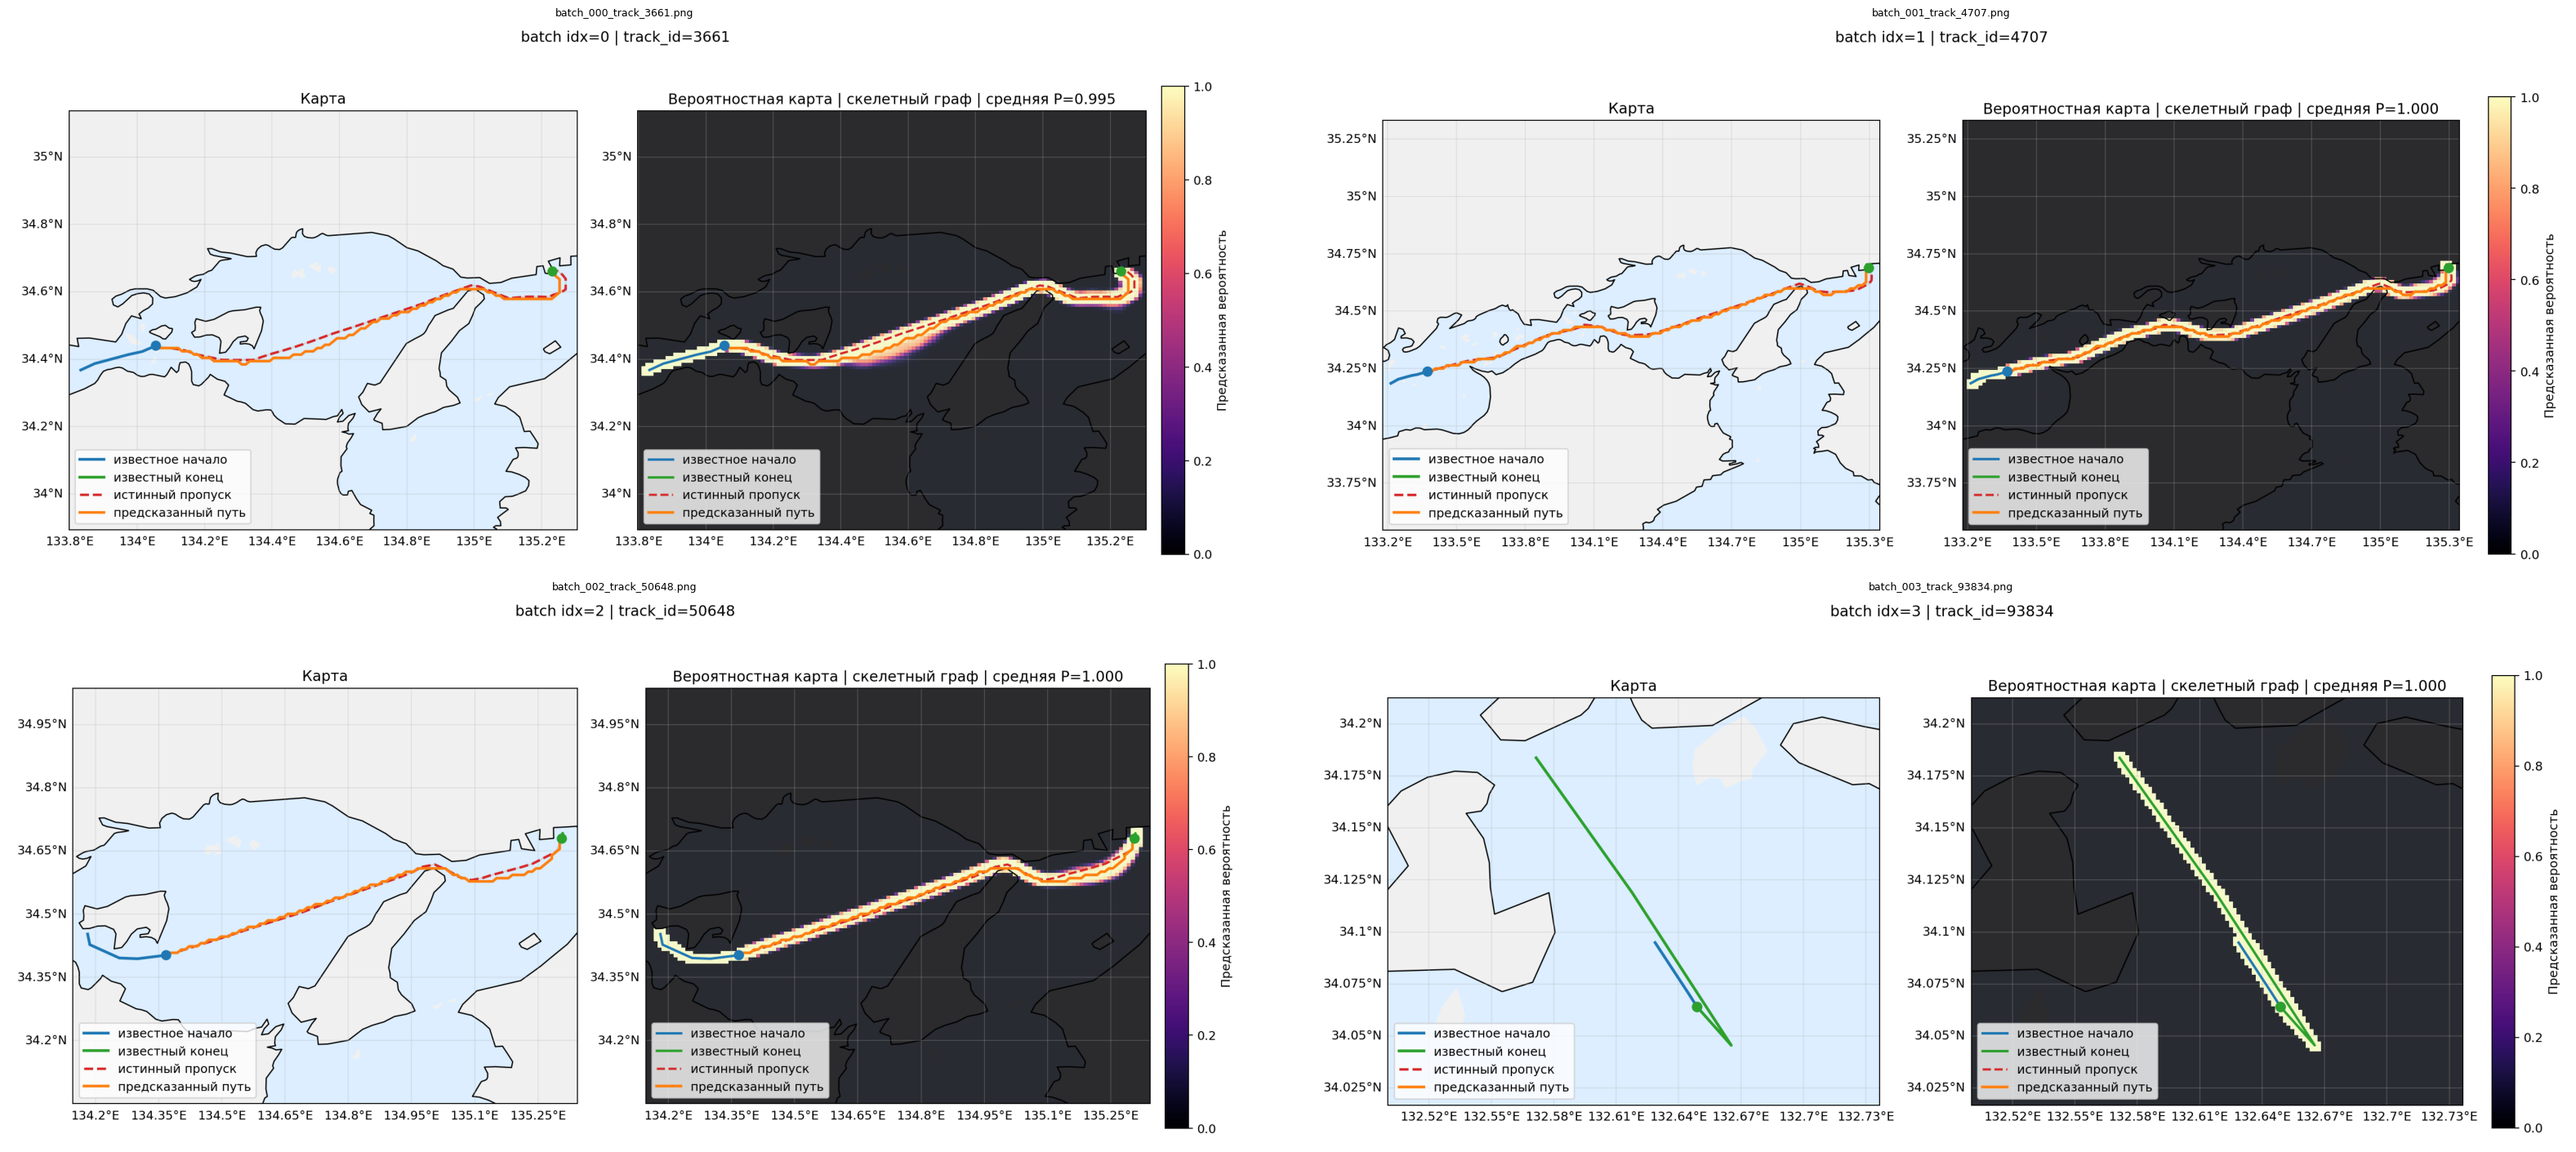

In [11]:
preview_paths = saved_paths[:4]
fig, axs = plt.subplots(2, 2, figsize=(32, 14), constrained_layout=True)
for ax, img_path in zip(axs.flat, preview_paths, strict=False):
    img = plt.imread(img_path)
    ax.imshow(img)
    ax.set_title(Path(img_path).name, fontsize=9)
    ax.axis('off')
for ax in axs.flat[len(preview_paths):]:
    ax.axis('off')
plt.show()

In [12]:
# Массовая генерация примеров восстановления маршрутов
# Индексы берутся из разных частей split, чтобы получить более разнообразные географии.
import random

MASS_SPLIT = 'val'  # можно заменить на 'train'
MASS_COUNT = 200
MASS_SEED = 20260519
MASS_OUT_DIR = OUT_DIR / f'mass_{MASS_SPLIT}_{MASS_COUNT}_routes'
ROUTE_SOURCE_LABELS = {
    'skeleton graph': 'скелетный граф',
    'A* fallback': 'резервный A*',
}
MASS_OUT_DIR.mkdir(parents=True, exist_ok=True)

mass_ds = val_ds if MASS_SPLIT == 'val' else train_ds
mass_rng = random.Random(MASS_SEED)
mass_count = min(MASS_COUNT, len(mass_ds))
mass_indices = []
for bucket_idx in range(mass_count):
    start = bucket_idx * len(mass_ds) // mass_count
    end = (bucket_idx + 1) * len(mass_ds) // mass_count
    mass_indices.append(mass_rng.randrange(start, max(start + 1, end)))
mass_rng.shuffle(mass_indices)

print('split     :', MASS_SPLIT)
print('count     :', len(mass_indices))
print('out dir   :', MASS_OUT_DIR)
print('idx range :', min(mass_indices), max(mass_indices))

split     : val
count     : 200
out dir   : runs/28-track-restore-mtlib/mass_val_200_routes
idx range : 1 1190


In [13]:
from tqdm.auto import tqdm

try:
    h5_is_open = bool(h5.id.valid)
except NameError:
    h5_is_open = False

if not h5_is_open:
    h5 = h5py.File(DATASET_PATH, 'r')

mass_rows = []
for order, idx in enumerate(tqdm(mass_indices, desc='Generate route figures')):
    example = mass_ds[idx]
    meta = example['meta']
    fragment = read_track_fragment(
        h5,
        mass_ds.track_index,
        meta['track_id'],
        meta['s'],
        meta['e'],
    )
    prob_map, result = predict_and_extract_route(
        model,
        example,
        fragment,
        grid_cfg=grid_cfg,
        device=device,
        extract_config=extract_cfg,
    )

    gap = tuple(meta['gaps'][0])
    out_path = MASS_OUT_DIR / (
        f'{order:03d}_idx_{idx:05d}_track_{int(meta["track_id"])}_'
        f's{int(meta["s"])}_e{int(meta["e"])}.png'
    )
    save_route_comparison_png(
        out_path,
        fragment,
        gap,
        meta['extent'],
        prob_map,
        result,
        title=(
            f'{MASS_SPLIT} idx={idx} | track_id={int(meta["track_id"])} | '
            f'{ROUTE_SOURCE_LABELS.get(result.path_source, result.path_source)} | '
            f'средняя P={result.mean_prob_on_path:.3f}'
        ),
    )
    mass_rows.append(
        {
            'order': order,
            'idx': int(idx),
            'split': MASS_SPLIT,
            'track_id': int(meta['track_id']),
            's': int(meta['s']),
            'e': int(meta['e']),
            'points': int(meta['points']),
            'gap': gap,
            'path_source': result.path_source,
            'path_len': int(len(result.path_cells)),
            'mean_prob_on_path': float(result.mean_prob_on_path),
            'graph_nodes': int(result.artifacts.graph.number_of_nodes()),
            'graph_edges': int(result.artifacts.graph.number_of_edges()),
            'image_path': str(out_path),
        }
    )

mass_summary = pd.DataFrame(mass_rows)
mass_summary_path = MASS_OUT_DIR / 'summary.csv'
mass_summary.to_csv(mass_summary_path, index=False)

print('saved figures:', len(mass_summary))
print('summary     :', mass_summary_path)
display(mass_summary.head(20))

Generate route figures: 100%|██████████| 200/200 [01:06<00:00,  3.01it/s]

saved figures: 200
summary     : runs/28-track-restore-mtlib/mass_val_200_routes/summary.csv


,order,idx,split,track_id,s,e,points,gap,path_source,path_len,mean_prob_on_path,graph_nodes,graph_edges,image_path
0,0,48,val,2620046,0,44,44,"(5, 39)",skeleton graph,123,0.998694,158,199,runs/28-track-restore-mtlib/mass_val_200_route...
1,1,1172,val,13743146,0,39,39,"(5, 34)",skeleton graph,143,0.998494,171,196,runs/28-track-restore-mtlib/mass_val_200_route...
2,2,1049,val,12986539,0,39,39,"(5, 34)",skeleton graph,106,0.999605,129,148,runs/28-track-restore-mtlib/mass_val_200_route...
3,3,608,val,8723597,73,113,40,"(5, 35)",skeleton graph,108,0.998706,140,179,runs/28-track-restore-mtlib/mass_val_200_route...
4,4,397,val,6808056,0,36,36,"(5, 31)",skeleton graph,108,0.999805,126,135,runs/28-track-restore-mtlib/mass_val_200_route...
5,5,900,val,11528645,51,112,61,"(14, 51)",skeleton graph,99,0.995935,161,179,runs/28-track-restore-mtlib/mass_val_200_route...
6,6,785,val,10576124,0,48,48,"(5, 43)",skeleton graph,134,0.994917,176,228,runs/28-track-restore-mtlib/mass_val_200_route...
7,7,225,val,5406307,0,33,33,"(5, 28)",skeleton graph,129,0.999573,151,152,runs/28-track-restore-mtlib/mass_val_200_route...
8,8,287,val,5803935,0,41,41,"(5, 36)",skeleton graph,109,0.999316,127,138,runs/28-track-restore-mtlib/mass_val_200_route...
9,9,887,val,11402428,5,37,32,"(5, 27)",skeleton graph,116,0.980545,209,276,runs/28-track-restore-mtlib/mass_val_200_route...


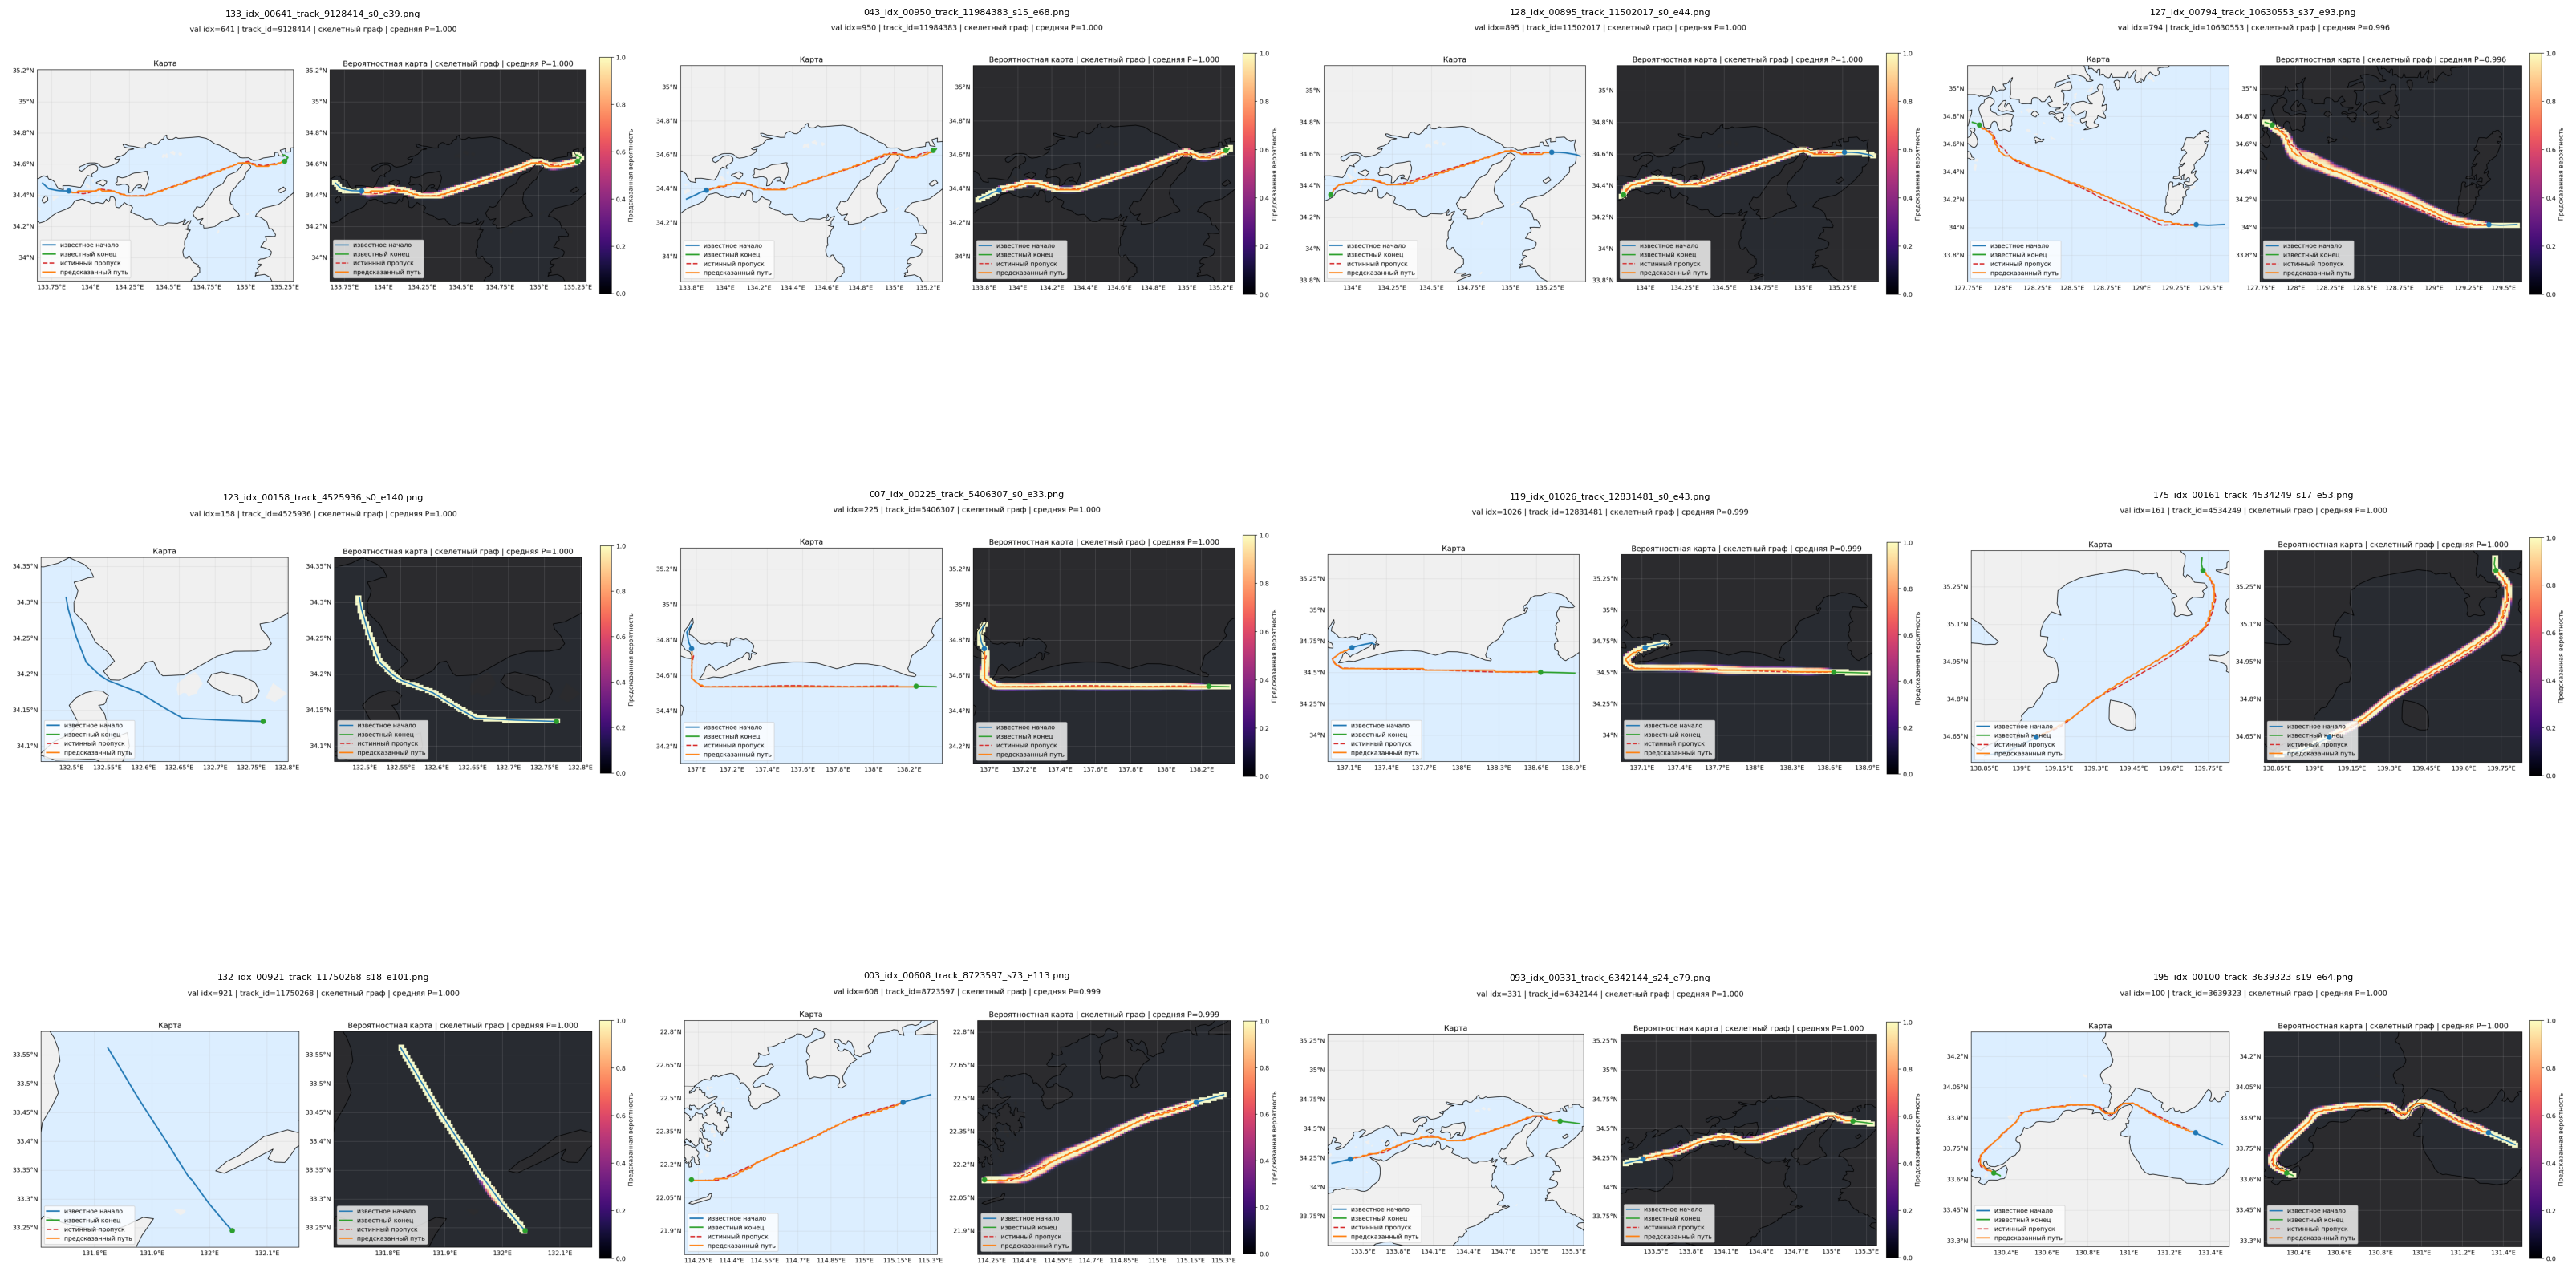

In [14]:
# Быстрый просмотр части сгенерированных картинок.
PREVIEW_COUNT = min(12, len(mass_summary))
preview_df = mass_summary.sample(PREVIEW_COUNT, random_state=MASS_SEED)

fig, axs = plt.subplots(3, 4, figsize=(32, 18), constrained_layout=True)
for ax, (_, row) in zip(axs.flat, preview_df.iterrows(), strict=False):
    img_path = Path(row['image_path'])
    img = plt.imread(img_path)
    ax.imshow(img)
    ax.set_title(img_path.name, fontsize=8)
    ax.axis('off')
for ax in axs.flat[PREVIEW_COUNT:]:
    ax.axis('off')
plt.show()